In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio scikit-learn pandas numpy matplotlib joblib -q

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/LSM_QuangTri")
BASE_DIR.mkdir(parents=True, exist_ok=True)

csv_path = BASE_DIR / "quangtri_inventory_with_features.csv"

raster_paths = {
    "elevation": BASE_DIR / "elevation_30m.tif",
    "slope": BASE_DIR / "slope_30m.tif",
    "aspect": BASE_DIR / "aspect_30m.tif",
    "lithology": BASE_DIR / "lithology_30m.tif",
    "distance_to_road": BASE_DIR / "distance_to_road_30m.tif",
    "distance_to_river": BASE_DIR / "distance_to_river_30m.tif",
    "landuse": BASE_DIR / "landuse_30m.tif",
    "rainfall": BASE_DIR / "rainfall_rainy_season_30m.tif",
    "plan_curvature": BASE_DIR / "plan_curvature_30m.tif",
    "twi": BASE_DIR / "twi_30m.tif",
    "ndvi": BASE_DIR / "ndvi_30m.tif",
}

# Output chính dùng ExtraTrees sau GridSearchCV
out_prob_tif = BASE_DIR / "extratrees_lsm_probability_30m.tif"
out_class_tif = BASE_DIR / "extratrees_lsm_binary_class_30m.tif"
out_class5_tif = BASE_DIR / "extratrees_lsm_susceptibility_5class_30m.tif"
out_png = BASE_DIR / "extratrees_lsm_probability.png"
out_class5_png = BASE_DIR / "extratrees_lsm_susceptibility_5class.png"
out_model = BASE_DIR / "extratrees_best_gridsearch_model.joblib"

print("CSV exists:", csv_path.exists(), "->", csv_path)
for k, v in raster_paths.items():
    print(k, v.exists(), v)

CSV exists: True -> /content/drive/MyDrive/LSM_QuangTri/quangtri_inventory_with_features.csv
elevation True /content/drive/MyDrive/LSM_QuangTri/elevation_30m.tif
slope True /content/drive/MyDrive/LSM_QuangTri/slope_30m.tif
aspect True /content/drive/MyDrive/LSM_QuangTri/aspect_30m.tif
lithology True /content/drive/MyDrive/LSM_QuangTri/lithology_30m.tif
distance_to_road True /content/drive/MyDrive/LSM_QuangTri/distance_to_road_30m.tif
distance_to_river True /content/drive/MyDrive/LSM_QuangTri/distance_to_river_30m.tif
landuse True /content/drive/MyDrive/LSM_QuangTri/landuse_30m.tif
rainfall True /content/drive/MyDrive/LSM_QuangTri/rainfall_rainy_season_30m.tif
plan_curvature True /content/drive/MyDrive/LSM_QuangTri/plan_curvature_30m.tif
twi True /content/drive/MyDrive/LSM_QuangTri/twi_30m.tif
ndvi False /content/drive/MyDrive/LSM_QuangTri/ndvi_30m.tif


In [ ]:
import numpy as np
import pandas as pd

encodings = ["utf-8-sig", "utf-8", "cp1252", "latin1", "cp1258"]

df = None
used_encoding = None

for enc in encodings:
    try:
        df = pd.read_csv(csv_path, encoding=enc)
        used_encoding = enc
        print("Read CSV successfully with encoding:", enc)
        break
    except UnicodeDecodeError:
        print("Failed encoding:", enc)

if df is None:
    raise UnicodeDecodeError("Không đọc được CSV với các encoding thử nghiệm.")

print("Original columns:")
print(df.columns.tolist())

# ============================================================
# Chuẩn hóa tên cột feature từ file point-sampling/QGIS
# ============================================================
candidate_features = [
    "elevation",
    "slope",
    "aspect_sin",
    "aspect_cos",
    "lithology",
    "distance_to_road",
    "distance_to_river",
    "landuse",
    "rainfall",
    "plan_curvature",
    "twi",
    "ndvi",
]

rename_map = {}
used_targets = set()

def add_rename(source_col, target_col):
    """Tránh rename nhiều cột về cùng một tên gây duplicate column."""
    if target_col not in used_targets and source_col != target_col:
        rename_map[source_col] = target_col
        used_targets.add(target_col)
    elif source_col == target_col:
        used_targets.add(target_col)

for col in df.columns:
    low = col.lower().strip()

    # Giữ nguyên nếu đã có aspect_sin/aspect_cos
    if "aspect_sin" in low:
        add_rename(col, "aspect_sin")
    elif "aspect_cos" in low:
        add_rename(col, "aspect_cos")
    elif "elevation" in low or low in ["dem", "elev"]:
        add_rename(col, "elevation")
    elif "slope" in low and "curvature" not in low:
        add_rename(col, "slope")
    elif low == "aspect" or low.startswith("aspect_"):
        add_rename(col, "aspect")
    elif "lithology" in low or "geology" in low:
        add_rename(col, "lithology")
    elif "road" in low:
        add_rename(col, "distance_to_road")
    elif "river" in low or "stream" in low:
        add_rename(col, "distance_to_river")
    elif "landuse" in low or "land_cover" in low or "landcover" in low or "lulc" in low:
        add_rename(col, "landuse")
    elif "rain" in low:
        add_rename(col, "rainfall")
    elif "curvature" in low or "tcurvature" in low or "plan" in low:
        add_rename(col, "plan_curvature")
    elif "twi" in low or "tci" in low:
        add_rename(col, "twi")
    elif "ndvi" in low:
        add_rename(col, "ndvi")

if rename_map:
    print("Rename map:")
    print(rename_map)
    df = df.rename(columns=rename_map)

# ============================================================
# Convert aspect degree -> sin/cos nếu CSV đang có aspect dạng độ
# ============================================================
if "aspect" in df.columns and ("aspect_sin" not in df.columns or "aspect_cos" not in df.columns):
    aspect_rad = np.deg2rad(pd.to_numeric(df["aspect"], errors="coerce"))
    df["aspect_sin"] = np.sin(aspect_rad)
    df["aspect_cos"] = np.cos(aspect_rad)
    df = df.drop(columns=["aspect"])

if "label" not in df.columns:
    raise ValueError("CSV chưa có cột label. Cần label = 1 cho landslide, 0 cho non-landslide.")

feature_cols = [c for c in candidate_features if c in df.columns]
if not feature_cols:
    raise ValueError("Không tìm thấy feature nào trong CSV. Kiểm tra lại tên cột hoặc rename_map.")

# Ép kiểu numeric để train sklearn và tính correlation
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["label"] = pd.to_numeric(df["label"], errors="coerce")

# Loại NoData phổ biến trước khi train
for c in feature_cols:
    df.loc[df[c].isin([-9999, 9999]), c] = np.nan

df = df.dropna(subset=feature_cols + ["label"]).copy()
df["label"] = df["label"].astype(int)

X = df[feature_cols].copy()      # giữ DataFrame để tên feature đi theo pipeline
y = df["label"].copy()

print("\nUsing features:", feature_cols)
print("Total samples:", len(df))
print("Landslide:", int((y == 1).sum()))
print("Non-landslide:", int((y == 0).sum()))
print("Class ratio landslide:", round(float((y == 1).mean()), 3))

display(df.head())

Failed encoding: utf-8-sig
Failed encoding: utf-8
Read CSV successfully with encoding: cp1252
Original columns:
['fid', 'lon', 'lat', 'label', 'layer', 'path', 'elevation_1', 'slope_1', 'aspect_1', 'lithology_1', 'road_1', 'river_1', 'landuse_1', 'rainfall_1', 'curvature_1', 'twi_1']
Rename map:
{'elevation_1': 'elevation', 'slope_1': 'slope', 'aspect_1': 'aspect', 'lithology_1': 'lithology', 'road_1': 'distance_to_road', 'river_1': 'distance_to_river', 'landuse_1': 'landuse', 'rainfall_1': 'rainfall', 'curvature_1': 'plan_curvature', 'twi_1': 'twi'}

Using features: ['elevation', 'slope', 'aspect_sin', 'aspect_cos', 'lithology', 'distance_to_road', 'distance_to_river', 'landuse', 'rainfall', 'plan_curvature', 'twi']
Total samples: 540
Landslide: 273
Non-landslide: 267
Class ratio landslide: 0.506


,fid,lon,lat,label,layer,path,elevation,slope,lithology,distance_to_road,distance_to_river,landuse,rainfall,plan_curvature,twi,aspect_sin,aspect_cos
0,1,106.947711,16.653988,1,landslide_new_utm48 — quangtri_landslide_inven...,landslide_new_utm48.gpkg|layername=quangtri_la...,30.0,10.272982,1.0,465.725250,94.868332,10.0,1688.432861,0.002145,6.729232,0.186451,9.824643e-01
1,2,106.984775,16.611622,1,landslide_new_utm48 — quangtri_landslide_inven...,landslide_new_utm48.gpkg|layername=quangtri_la...,462.0,40.655422,5.0,3351.686035,2224.455078,60.0,1722.578369,0.000952,4.854030,-0.275389,9.613329e-01
2,3,106.978877,16.563544,1,landslide_new_utm48 — quangtri_landslide_inven...,landslide_new_utm48.gpkg|layername=quangtri_la...,171.0,12.803420,5.0,573.149170,429.534637,10.0,1690.011475,0.001693,5.490458,0.074315,9.972348e-01
3,4,106.987957,16.470563,1,landslide_new_utm48 — quangtri_landslide_inven...,landslide_new_utm48.gpkg|layername=quangtri_la...,254.0,36.602741,5.0,123.693169,90.000000,10.0,1619.109375,-0.001404,4.869613,1.000000,6.123234e-17
4,5,106.981717,16.460647,1,landslide_new_utm48 — quangtri_landslide_inven...,landslide_new_utm48.gpkg|layername=quangtri_la...,245.0,29.835367,2.0,161.554947,67.082039,10.0,1619.109375,0.000931,5.363750,0.647488,-7.620758e-01


In [ ]:
BASE_DIR = Path("/content/drive/MyDrive/LSM_QuangTri")

Number of features: 11
Features: ['elevation', 'slope', 'aspect_sin', 'aspect_cos', 'lithology', 'distance_to_road', 'distance_to_river', 'landuse', 'rainfall', 'plan_curvature', 'twi']
Output dir: /content/drive/MyDrive/LSM_QuangTri/lsm_model_compare
Số feature dùng để phân tích tương quan: 11
Danh sách feature: ['elevation', 'slope', 'aspect_sin', 'aspect_cos', 'lithology', 'distance_to_road', 'distance_to_river', 'landuse', 'rainfall', 'plan_curvature', 'twi']
Có thêm label để tính tương quan với nhãn.

Feature hợp lệ sau khi xử lý: 12
['elevation', 'slope', 'aspect_sin', 'aspect_cos', 'lithology', 'distance_to_road', 'distance_to_river', 'landuse', 'rainfall', 'plan_curvature', 'twi', 'label']


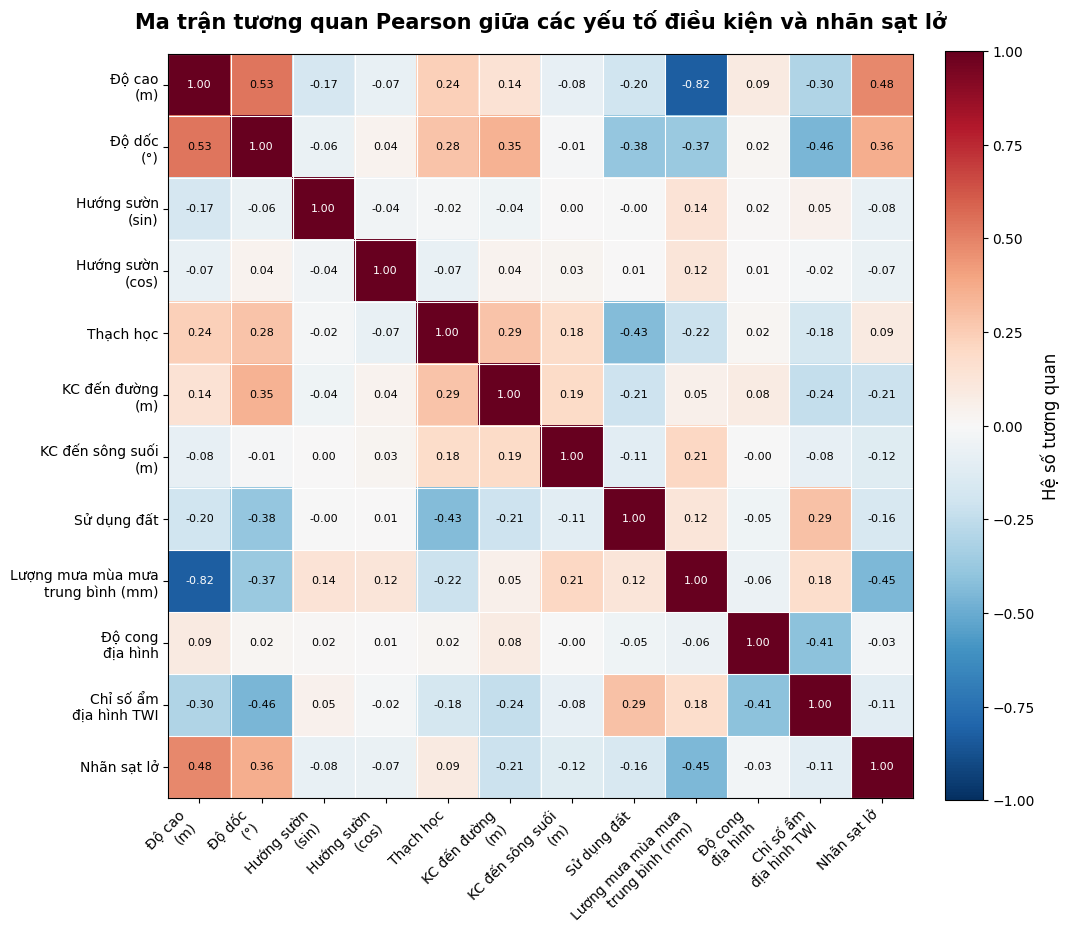

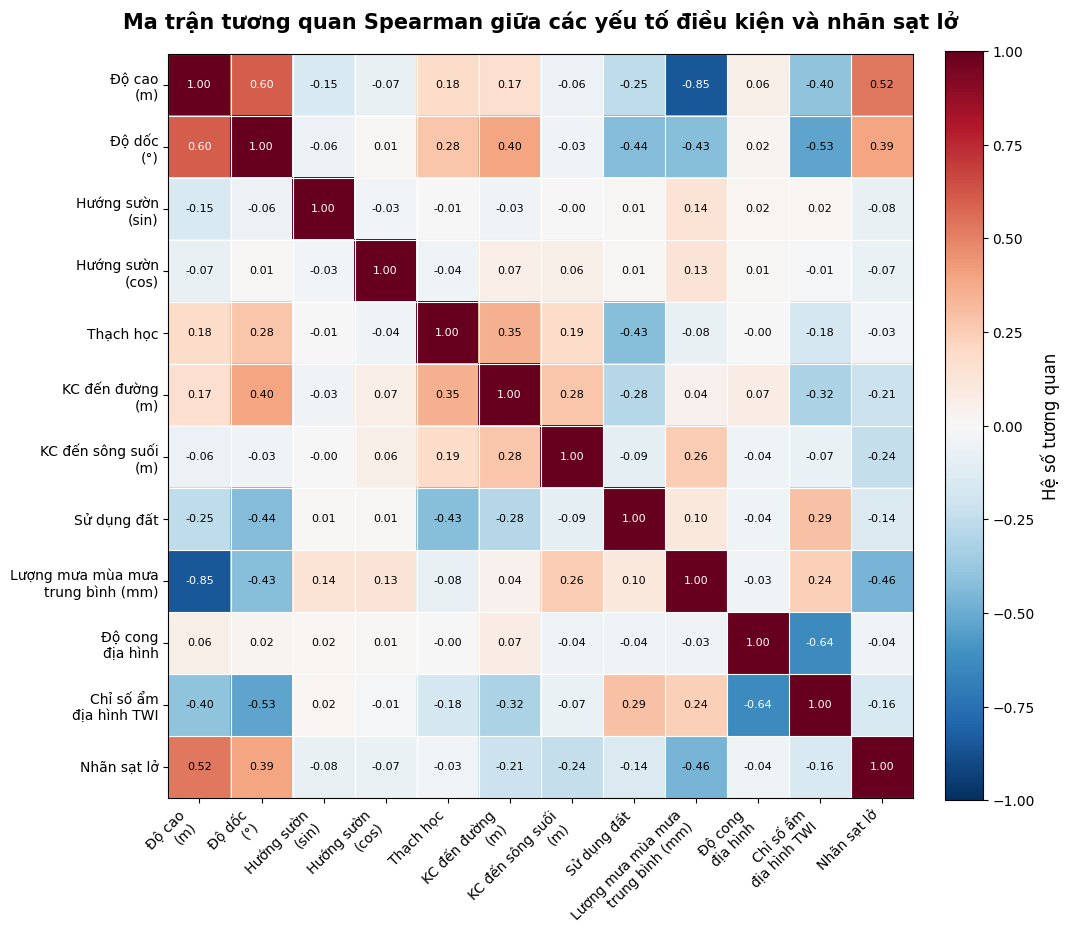


Tương quan giữa từng feature và nhãn sạt lở:


,feature,feature_vi,pearson_corr_with_label,abs_pearson,spearman_corr_with_label,abs_spearman
0,elevation,Độ cao (m),0.476667,0.476667,0.523964,0.523964
1,rainfall,Lượng mưa mùa mưa trung bình (mm),-0.446044,0.446044,-0.464195,0.464195
2,slope,Độ dốc (°),0.362119,0.362119,0.391995,0.391995
3,distance_to_river,KC đến sông suối (m),-0.121992,0.121992,-0.238377,0.238377
4,distance_to_road,KC đến đường (m),-0.212875,0.212875,-0.214868,0.214868
5,twi,Chỉ số ẩm địa hình TWI,-0.107344,0.107344,-0.156191,0.156191
6,landuse,Sử dụng đất,-0.158827,0.158827,-0.141438,0.141438
7,aspect_sin,Hướng sườn (sin),-0.077576,0.077576,-0.075801,0.075801
8,aspect_cos,Hướng sườn (cos),-0.068555,0.068555,-0.067769,0.067769
9,plan_curvature,Độ cong địa hình,-0.027022,0.027022,-0.044112,0.044112


Saved feature-label correlation table: /content/drive/MyDrive/LSM_QuangTri/lsm_model_compare/correlation_analysis/feature_correlation_with_label.csv


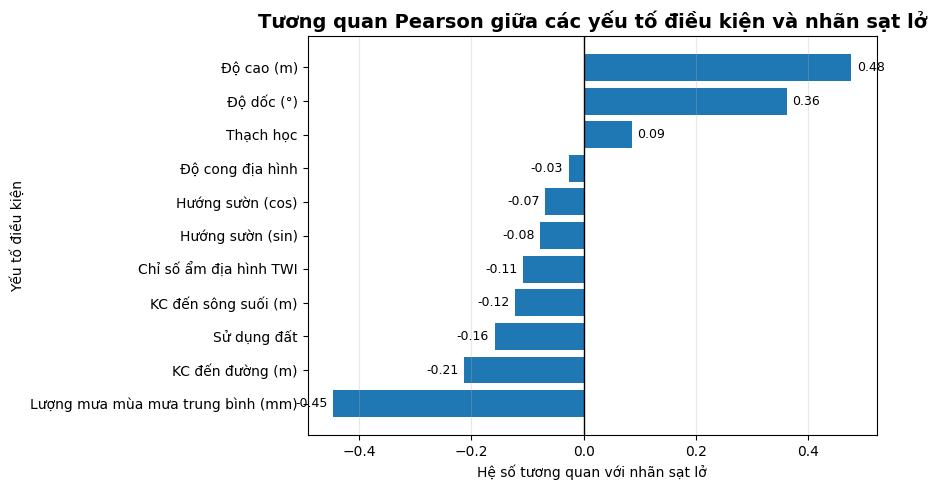

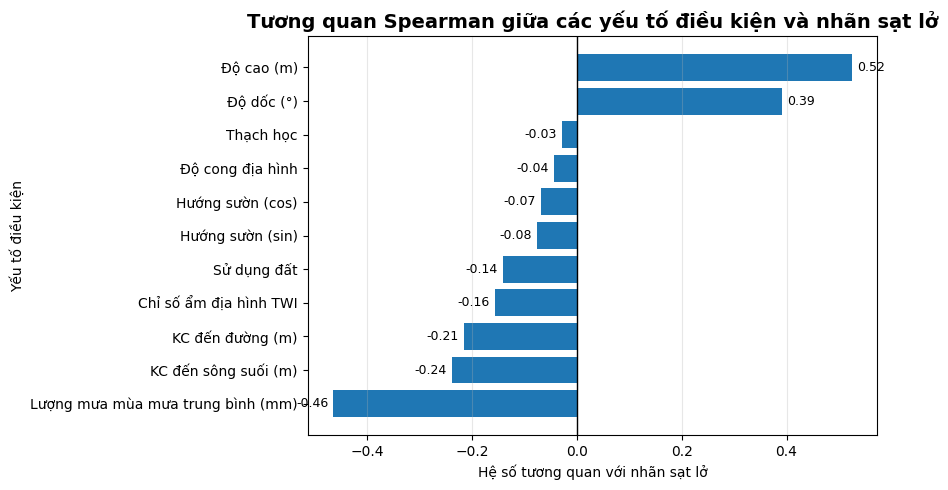


Các cặp biến có tương quan cao | ngưỡng |r| >= 0.85:


,feature_1,feature_2,correlation,abs_correlation,method



Đã lưu kết quả correlation tại: /content/drive/MyDrive/LSM_QuangTri/lsm_model_compare/correlation_analysis
Train samples: 432 | Test samples: 108
Train landslide: 218 | Train non-landslide: 214
Test landslide: 55 | Test non-landslide: 53

GridSearchCV - ExtraTrees
Fitting 5 folds for each of 2160 candidates, totalling 10800 fits


In [ ]:
# ============================================================
# CORRELATION + GRIDSEARCH EXTRATREES + MODEL COMPARISON
# ExtraTrees là model chính; Logistic Regression, SVM, RandomForest để so sánh.
# Có phân tích tương quan giữa feature với label.
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    log_loss,
)
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

try:
    from IPython.display import display
except ImportError:
    display = print


# ============================================================
# CONFIG
# ============================================================
RANDOM_STATE = 42
TEST_SIZE = 0.20
GRID_CV_SPLITS = 5
GRID_N_JOBS = -1
HIGH_CORR_THRESHOLD = 0.85

MODEL_OUT_DIR = BASE_DIR / "lsm_model_compare"
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Nếu out_model chưa khai báo ở cell trước thì tự tạo
try:
    out_model
except NameError:
    out_model = MODEL_OUT_DIR / "best_extratrees_gridsearch_model.pkl"

X_model = X.copy()
y_model = y.copy()

# Đảm bảo y_model là Series cùng index với X_model
if not isinstance(y_model, pd.Series):
    y_model = pd.Series(y_model, index=X_model.index, name="label")
else:
    y_model = y_model.reindex(X_model.index)
    y_model.name = "label"

feature_names = list(X_model.columns)

print("Number of features:", len(feature_names))
print("Features:", feature_names)
print("Output dir:", MODEL_OUT_DIR)


# ============================================================
# 1) CORRELATION FEATURE ANALYSIS
# Pearson + Spearman correlation matrix
# Có số trong ô + tên feature tiếng Việt
# Có thêm label để xem biến tương quan với nhãn sạt lở
# ============================================================

CORR_OUT_DIR = MODEL_OUT_DIR / "correlation_analysis"
CORR_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Feature columns đúng theo mô hình
# ------------------------------------------------------------
feature_cols = [
    "elevation",
    "slope",
    "aspect_sin",
    "aspect_cos",
    "lithology",
    "distance_to_road",
    "distance_to_river",
    "landuse",
    "rainfall",
    "plan_curvature",
    "twi",
]

# Ghép X_model + y_model để tính tương quan với nhãn
df_corr = X_model.copy()
df_corr["label"] = y_model

corr_cols = [c for c in feature_cols if c in df_corr.columns]
corr_cols_with_label = corr_cols + ["label"]

print("Số feature dùng để phân tích tương quan:", len(corr_cols))
print("Danh sách feature:", corr_cols)
print("Có thêm label để tính tương quan với nhãn.")


# ------------------------------------------------------------
# Tên feature tiếng Việt
# ------------------------------------------------------------
FEATURE_NAME_VI = {
    "elevation": "Độ cao\n(m)",
    "slope": "Độ dốc\n(°)",
    "aspect_sin": "Hướng sườn\n(sin)",
    "aspect_cos": "Hướng sườn\n(cos)",
    "lithology": "Thạch học",
    "distance_to_road": "KC đến đường\n(m)",
    "distance_to_river": "KC đến sông suối\n(m)",
    "landuse": "Sử dụng đất",
    "rainfall": "Lượng mưa mùa mưa\ntrung bình (mm)",
    "plan_curvature": "Độ cong\nđịa hình",
    "twi": "Chỉ số ẩm\nđịa hình TWI",
    "label": "Nhãn sạt lở",
}

def feature_name_vi(name):
    return FEATURE_NAME_VI.get(name, name)


# ------------------------------------------------------------
# Prepare dataframe for correlation
# ------------------------------------------------------------
X_corr = df_corr[corr_cols_with_label].copy()

encoding_maps = {}

for c in X_corr.columns:
    numeric_col = pd.to_numeric(X_corr[c], errors="coerce")

    # Nếu cột có đủ giá trị số thì dùng trực tiếp
    if numeric_col.notna().sum() >= max(2, int(0.5 * len(X_corr))):
        X_corr[c] = numeric_col
    else:
        # Nếu categorical dạng text thì mã hóa tạm để tính tương quan
        codes, uniques = pd.factorize(X_corr[c].astype(str), sort=True)
        X_corr[c] = codes.astype(float)

        encoding_maps[c] = {
            int(i): str(v) for i, v in enumerate(uniques)
        }

# Bỏ cột toàn NaN hoặc chỉ có 1 giá trị
valid_cols = []
for c in X_corr.columns:
    if X_corr[c].notna().sum() > 1 and X_corr[c].nunique(dropna=True) > 1:
        valid_cols.append(c)

X_corr = X_corr[valid_cols]

print("\nFeature hợp lệ sau khi xử lý:", len(valid_cols))
print(valid_cols)

if len(encoding_maps) > 0:
    print("\nCác cột categorical đã được mã hóa tạm để tính tương quan:")
    for col, mapping in encoding_maps.items():
        print(f"- {col}: {mapping}")


# ------------------------------------------------------------
# Calculate correlation matrices
# ------------------------------------------------------------
corr_pearson = X_corr.corr(method="pearson")
corr_spearman = X_corr.corr(method="spearman")

# Save original-name CSV
corr_pearson.to_csv(
    CORR_OUT_DIR / "feature_correlation_pearson_with_label.csv",
    encoding="utf-8-sig"
)

corr_spearman.to_csv(
    CORR_OUT_DIR / "feature_correlation_spearman_with_label.csv",
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Rename matrix to Vietnamese names
# ------------------------------------------------------------
def rename_corr_matrix_to_vietnamese(corr_matrix):
    return corr_matrix.rename(
        index=lambda x: feature_name_vi(x),
        columns=lambda x: feature_name_vi(x)
    )

corr_pearson_vi = rename_corr_matrix_to_vietnamese(corr_pearson)
corr_spearman_vi = rename_corr_matrix_to_vietnamese(corr_spearman)

corr_pearson_vi.to_csv(
    CORR_OUT_DIR / "feature_correlation_pearson_with_label_vi.csv",
    encoding="utf-8-sig"
)

corr_spearman_vi.to_csv(
    CORR_OUT_DIR / "feature_correlation_spearman_with_label_vi.csv",
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Plot correlation heatmap with values inside cells
# ------------------------------------------------------------
def plot_corr_matrix(corr_matrix, title, save_path):
    n = corr_matrix.shape[0]

    fig_size = max(10, n * 0.9)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    im = ax.imshow(
        corr_matrix.values,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1
    )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Hệ số tương quan", fontsize=12)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(
        corr_matrix.columns,
        rotation=45,
        ha="right",
        fontsize=10
    )

    ax.set_yticklabels(
        corr_matrix.index,
        fontsize=10
    )

    # Ghi số trong từng ô
    for i in range(n):
        for j in range(n):
            value = corr_matrix.iloc[i, j]

            if pd.isna(value):
                text = ""
                text_color = "black"
            else:
                text = f"{value:.2f}"
                text_color = "white" if abs(value) >= 0.60 else "black"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
                color=text_color
            )

    # Vẽ lưới ô
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)

    ax.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=0.8
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=18
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# Plot Pearson matrix with label
# ------------------------------------------------------------
plot_corr_matrix(
    corr_pearson_vi,
    "Ma trận tương quan Pearson giữa các yếu tố điều kiện và nhãn sạt lở",
    CORR_OUT_DIR / "feature_correlation_pearson_with_label_vi.png"
)

# ------------------------------------------------------------
# Plot Spearman matrix with label
# ------------------------------------------------------------
plot_corr_matrix(
    corr_spearman_vi,
    "Ma trận tương quan Spearman giữa các yếu tố điều kiện và nhãn sạt lở",
    CORR_OUT_DIR / "feature_correlation_spearman_with_label_vi.png"
)


# ============================================================
# 1.1) FEATURE - LABEL CORRELATION TABLE
# Bảng riêng: từng feature tương quan với label
# ============================================================

if "label" in corr_pearson.columns and "label" in corr_spearman.columns:
    corr_label_pearson = (
        corr_pearson["label"]
        .drop("label")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

    corr_label_spearman = (
        corr_spearman["label"]
        .drop("label")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

    label_corr_df = pd.DataFrame({
        "feature": corr_label_pearson.index,
        "feature_vi": [
            feature_name_vi(f).replace("\n", " ")
            for f in corr_label_pearson.index
        ],
        "pearson_corr_with_label": corr_label_pearson.values,
        "abs_pearson": corr_label_pearson.abs().values,
        "spearman_corr_with_label": corr_label_spearman.reindex(corr_label_pearson.index).values,
        "abs_spearman": corr_label_spearman.reindex(corr_label_pearson.index).abs().values,
    })

    label_corr_df = label_corr_df.sort_values(
        "abs_spearman",
        ascending=False
    ).reset_index(drop=True)

    label_corr_csv = CORR_OUT_DIR / "feature_correlation_with_label.csv"
    label_corr_df.to_csv(label_corr_csv, index=False, encoding="utf-8-sig")

    print("\nTương quan giữa từng feature và nhãn sạt lở:")
    display(label_corr_df)
    print("Saved feature-label correlation table:", label_corr_csv)


    # ------------------------------------------------------------
    # Plot feature-label correlation bar chart
    # ------------------------------------------------------------
    def plot_feature_label_corr(corr_series, title, save_path):
        plot_series = corr_series.copy()

        plot_series.index = [
            feature_name_vi(f).replace("\n", " ")
            for f in plot_series.index
        ]

        plot_series = plot_series.sort_values()

        plt.figure(figsize=(9, max(5, len(plot_series) * 0.45)))
        plt.barh(plot_series.index, plot_series.values)

        plt.axvline(0, color="black", linewidth=1)
        plt.xlabel("Hệ số tương quan với nhãn sạt lở")
        plt.ylabel("Yếu tố điều kiện")
        plt.title(title, fontsize=14, fontweight="bold")
        plt.grid(axis="x", alpha=0.3)

        # Ghi số ở cuối thanh
        for i, value in enumerate(plot_series.values):
            ha = "left" if value >= 0 else "right"
            offset = 0.01 if value >= 0 else -0.01

            plt.text(
                value + offset,
                i,
                f"{value:.2f}",
                va="center",
                ha=ha,
                fontsize=9
            )

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()


    plot_feature_label_corr(
        corr_label_pearson,
        "Tương quan Pearson giữa các yếu tố điều kiện và nhãn sạt lở",
        CORR_OUT_DIR / "feature_label_correlation_pearson.png"
    )

    plot_feature_label_corr(
        corr_label_spearman,
        "Tương quan Spearman giữa các yếu tố điều kiện và nhãn sạt lở",
        CORR_OUT_DIR / "feature_label_correlation_spearman.png"
    )

else:
    print("Không tìm thấy cột label trong ma trận tương quan.")


# ------------------------------------------------------------
# Extract high-correlation feature pairs
# gồm cả label nếu đạt ngưỡng HIGH_CORR_THRESHOLD
# ------------------------------------------------------------
def get_high_corr_pairs(corr_matrix, threshold=HIGH_CORR_THRESHOLD, method_name=""):
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
            0: "correlation"
        })
    )

    pairs["abs_correlation"] = pairs["correlation"].abs()
    pairs = pairs[pairs["abs_correlation"] >= threshold]
    pairs = pairs.sort_values("abs_correlation", ascending=False)
    pairs["method"] = method_name

    return pairs

high_corr_pearson = get_high_corr_pairs(
    corr_pearson,
    threshold=HIGH_CORR_THRESHOLD,
    method_name="Pearson"
)

high_corr_spearman = get_high_corr_pairs(
    corr_spearman,
    threshold=HIGH_CORR_THRESHOLD,
    method_name="Spearman"
)

high_corr_all = pd.concat(
    [high_corr_pearson, high_corr_spearman],
    ignore_index=True
)

if len(high_corr_all) > 0:
    high_corr_all["feature_1_vi"] = high_corr_all["feature_1"].map(
        lambda x: feature_name_vi(x).replace("\n", " ")
    )

    high_corr_all["feature_2_vi"] = high_corr_all["feature_2"].map(
        lambda x: feature_name_vi(x).replace("\n", " ")
    )

    high_corr_all = high_corr_all[
        [
            "method",
            "feature_1",
            "feature_1_vi",
            "feature_2",
            "feature_2_vi",
            "correlation",
            "abs_correlation"
        ]
    ]

high_corr_all.to_csv(
    CORR_OUT_DIR / "high_correlation_feature_pairs.csv",
    index=False,
    encoding="utf-8-sig"
)

print(f"\nCác cặp biến có tương quan cao | ngưỡng |r| >= {HIGH_CORR_THRESHOLD}:")
display(high_corr_all)

print("\nĐã lưu kết quả correlation tại:", CORR_OUT_DIR)


# ============================================================
# 2) TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_model,
)

print("Train samples:", len(X_train), "| Test samples:", len(X_test))
print("Train landslide:", int((y_train == 1).sum()), "| Train non-landslide:", int((y_train == 0).sum()))
print("Test landslide:", int((y_test == 1).sum()), "| Test non-landslide:", int((y_test == 0).sum()))

cv = StratifiedKFold(
    n_splits=GRID_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# 3) GRIDSEARCHCV CHO EXTRATREES
# ============================================================
extra_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
    )),
])

extra_param_grid = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [None, 10, 20, 30],
    "model__max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    estimator=extra_pipe,
    param_grid=extra_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=GRID_N_JOBS,
    refit=True,
    verbose=1,
    return_train_score=True,
)

print("\n" + "=" * 80)
print("GridSearchCV - ExtraTrees")
print("=" * 80)

grid_search.fit(X_train, y_train)

best_extra_model = grid_search.best_estimator_
best_extra_params = grid_search.best_params_
best_extra_cv_auc = grid_search.best_score_

print("Best CV AUC:", best_extra_cv_auc)
print("Best params:")
print(best_extra_params)

# Lưu toàn bộ kết quả gridsearch
cv_results_df = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")
cv_results_csv = MODEL_OUT_DIR / "extratrees_gridsearch_cv_results.csv"
cv_results_df.to_csv(cv_results_csv, index=False, encoding="utf-8-sig")
print("Saved GridSearch results:", cv_results_csv)

grid_path = MODEL_OUT_DIR / "extratrees_gridsearch_object.pkl"
joblib.dump(grid_search, grid_path)
print("Saved GridSearch object:", grid_path)


# ============================================================
# 4) TRAIN THÊM MODEL TUYẾN TÍNH, SVM, RANDOM FOREST ĐỂ SO SÁNH
# ============================================================
trained_models = {
    "ExtraTrees_GridSearch": best_extra_model,

    "Linear_LogisticRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ]),

    "SVM_RBF": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),

    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            criterion="entropy",
            max_depth=None,
            max_features="sqrt",
            min_samples_leaf=1,
            min_samples_split=2,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
        )),
    ]),
}

summary_rows = []
reports = {}
predictions_by_model = {}

plt.figure(figsize=(8, 6))

for model_name, clf in trained_models.items():
    print("\n" + "=" * 80)
    print("Training / Evaluating:", model_name)
    print("=" * 80)

    # ExtraTrees đã fit trong GridSearchCV, model khác mới fit
    if model_name != "ExtraTrees_GridSearch":
        clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    ll = log_loss(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    report_dict = classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        output_dict=True,
        zero_division=0
    )

    report_text = classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Non-landslide", "Landslide"],
        zero_division=0
    )

    print("Accuracy:", acc)
    print("Balanced accuracy:", bal_acc)
    print("AUC ROC:", auc)
    print("LogLoss:", ll)
    print("Confusion matrix [0,1]:")
    print(cm)
    print("Classification report:")
    print(report_text)

    reports[model_name] = report_dict

    predictions_by_model[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix": cm,
    }

    summary_rows.append({
        "model": model_name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "auc_roc": auc,
        "logloss": ll,
        "precision_non_landslide": report_dict["0"]["precision"],
        "recall_non_landslide": report_dict["0"]["recall"],
        "f1_non_landslide": report_dict["0"]["f1-score"],
        "precision_landslide": report_dict["1"]["precision"],
        "recall_landslide": report_dict["1"]["recall"],
        "f1_landslide": report_dict["1"]["f1-score"],
        "f1_macro": report_dict["macro avg"]["f1-score"],
    })

    report_df = pd.DataFrame(report_dict).transpose()
    report_path = MODEL_OUT_DIR / f"{model_name}_classification_report.csv"
    report_df.to_csv(report_path, encoding="utf-8-sig")

    model_path = MODEL_OUT_DIR / f"{model_name}_pipeline.pkl"
    joblib.dump(clf, model_path)

    print("Saved model:", model_path)
    print("Saved classification report:", report_path)

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=f"{model_name} AUC={auc:.3f}",
        ax=plt.gca(),
    )

plt.title("ROC Curves - LSM Models")
plt.grid(True, alpha=0.3)
plt.tight_layout()

roc_path = MODEL_OUT_DIR / "roc_curves_model_comparison.png"
plt.savefig(roc_path, dpi=300)
plt.show()

print("Saved ROC curve:", roc_path)


# ============================================================
# 5) BẢNG SO SÁNH MODEL
# ============================================================
summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("auc_roc", ascending=False)
    .reset_index(drop=True)
)

summary_csv = MODEL_OUT_DIR / "model_comparison_summary.csv"
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

print("\nBảng so sánh model:")
display(summary_df)
print("Saved summary:", summary_csv)

# Model chính dùng cho bản đồ LSM: ExtraTrees sau GridSearchCV
best_model_name = "ExtraTrees_GridSearch"
best_model = trained_models[best_model_name]
model = best_model

joblib.dump(best_model, out_model)
print("Saved best ExtraTrees model:", out_model)


# ============================================================
# 6) FEATURE IMPORTANCE CỦA EXTRATREES TỐT NHẤT
# ============================================================
extra_clf = best_model.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "feature_vi": [
        feature_name_vi(f).replace("\n", " ")
        for f in feature_names
    ],
    "importance": extra_clf.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_csv = MODEL_OUT_DIR / "extratrees_feature_importance.csv"
importance_df.to_csv(importance_csv, index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, max(5, len(feature_names) * 0.35)))

plot_df = importance_df.iloc[::-1]

plt.barh(plot_df["feature_vi"], plot_df["importance"])
plt.xlabel("Mức độ quan trọng")
plt.ylabel("Yếu tố điều kiện")
plt.title("ExtraTrees - Mức độ quan trọng của các yếu tố điều kiện")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

importance_png = MODEL_OUT_DIR / "extratrees_feature_importance.png"
plt.savefig(importance_png, dpi=300)
plt.show()

print("Saved feature importance CSV:", importance_csv)
print("Saved feature importance PNG:", importance_png)
display(importance_df)

In [ ]:
# ============================================================
# PLOT MODEL COMPARISON METRICS
# ============================================================

import matplotlib.pyplot as plt

metric_cols = ["auc_roc", "f1_landslide", "recall_landslide", "accuracy", "balanced_accuracy"]
plot_df = summary_df.set_index("model")[metric_cols]

plt.figure(figsize=(11, 6))
plot_df.plot(kind="bar", figsize=(11, 6))
plt.title("So sánh hiệu quả các mô hình LSM")
plt.xlabel("Mô hình")
plt.ylabel("Giá trị")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Chỉ số", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

comparison_png = MODEL_OUT_DIR / "model_comparison_metrics.png"
plt.savefig(comparison_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", comparison_png)

In [ ]:
# ============================================================
# CONFUSION MATRICES FOR MODEL COMPARISON
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for model_name, pred_info in predictions_by_model.items():
    cm = pred_info["confusion_matrix"]

    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Không sạt lở", "Sạt lở"],
    )
    disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False,
    cmap="Blues"
    )

    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    cm_png = MODEL_OUT_DIR / f"{model_name}_confusion_matrix.png"
    plt.savefig(cm_png, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", cm_png)

In [ ]:
# ============================================================
# PREDICT RASTER MAPS - BEST EXTRATREES ONLY
# Probability map + binary class map + 5-class susceptibility map
# ============================================================

import rasterio
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

MAP_OUT_DIR = BASE_DIR / "lsm_maps_extratrees"
MAP_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# READ RASTER STACK THEO ĐÚNG THỨ TỰ feature_cols
# ============================================================
arrays = []
nodata_masks = []
profile = None
ref_shape = None
ref_crs = None

for name in feature_cols:
    if name in ["aspect_sin", "aspect_cos"]:
        path = raster_paths["aspect"]
    else:
        path = raster_paths[name]

    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy raster: {path}")

    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")

        if profile is None:
            profile = src.profile.copy()
            ref_shape = arr.shape
            ref_crs = src.crs
        else:
            if arr.shape != ref_shape:
                raise ValueError(f"Raster {name} khác kích thước với raster đầu tiên.")
            if src.crs != ref_crs:
                raise ValueError(f"Raster {name} khác CRS với raster đầu tiên.")

        nodata = src.nodata
        if nodata is not None:
            mask = arr == nodata
        else:
            mask = np.isnan(arr)

        mask = mask | (arr == -9999) | (arr == 9999)

        if name == "aspect_sin":
            arr = np.sin(np.deg2rad(arr))
        elif name == "aspect_cos":
            arr = np.cos(np.deg2rad(arr))

        arrays.append(arr)
        nodata_masks.append(mask)

stack = np.stack(arrays, axis=-1)
invalid_mask = np.any(np.stack(nodata_masks, axis=-1), axis=-1)
invalid_mask = invalid_mask | np.any(np.isnan(stack), axis=-1)

rows, cols, bands = stack.shape
print("Raster stack shape:", stack.shape)
print("CRS:", ref_crs)
print("Features used:", feature_cols)
print("Valid pixels:", int(np.sum(~invalid_mask)))
print("Invalid pixels:", int(np.sum(invalid_mask)))

flat = stack.reshape(-1, bands)
flat_invalid = invalid_mask.reshape(-1)
valid_pixels = flat[~flat_invalid]
valid_pixels_df = pd.DataFrame(valid_pixels, columns=feature_cols)

# ============================================================
# DÙNG MODEL CHÍNH: EXTRATREES SAU GRIDSEARCHCV
# ============================================================
if "best_model" not in globals():
    raise RuntimeError("Chưa có best_model. Hãy chạy cell GridSearchCV + model comparison trước.")

print("Predicting raster with:", best_model_name)

prob = np.full(flat.shape[0], -9999, dtype="float32")
cls = np.full(flat.shape[0], 255, dtype="uint8")

prob_valid = best_model.predict_proba(valid_pixels_df)[:, 1].astype("float32")
cls_valid = (prob_valid >= 0.5).astype("uint8")

prob[~flat_invalid] = prob_valid
cls[~flat_invalid] = cls_valid

prob_map = prob.reshape(rows, cols)
class_map = cls.reshape(rows, cols)

# ============================================================
# EXPORT GEOTIFF
# ============================================================
prob_profile = profile.copy()
prob_profile.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999,
    "compress": "lzw",
})

class_profile = profile.copy()
class_profile.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "uint8",
    "nodata": 255,
    "compress": "lzw",
})

out_prob_tif = MAP_OUT_DIR / "ExtraTrees_lsm_probability_30m.tif"
out_class_tif = MAP_OUT_DIR / "ExtraTrees_lsm_binary_class_30m.tif"
out_class5_tif = MAP_OUT_DIR / "ExtraTrees_lsm_susceptibility_5class_30m.tif"
out_png = MAP_OUT_DIR / "ExtraTrees_lsm_probability.png"
out_class5_png = MAP_OUT_DIR / "ExtraTrees_lsm_susceptibility_5class.png"

with rasterio.open(out_prob_tif, "w", **prob_profile) as dst:
    dst.write(prob_map, 1)

with rasterio.open(out_class_tif, "w", **class_profile) as dst:
    dst.write(class_map, 1)

print("Saved probability map:", out_prob_tif)
print("Saved binary class map:", out_class_tif)

# ============================================================
# 5-CLASS SUSCEPTIBILITY MAP
# ============================================================
classes_5 = np.full(prob_map.shape, 255, dtype="uint8")
valid = prob_map != -9999

classes_5[(prob_map >= 0.0) & (prob_map < 0.2) & valid] = 1
classes_5[(prob_map >= 0.2) & (prob_map < 0.4) & valid] = 2
classes_5[(prob_map >= 0.4) & (prob_map < 0.6) & valid] = 3
classes_5[(prob_map >= 0.6) & (prob_map < 0.8) & valid] = 4
classes_5[(prob_map >= 0.8) & (prob_map <= 1.0) & valid] = 5

with rasterio.open(out_class5_tif, "w", **class_profile) as dst:
    dst.write(classes_5, 1)

print("Saved 5-class GeoTIFF:", out_class5_tif)

In [ ]:
# ============================================================
# SAVE TRAINED MODEL PIPELINES + METADATA
# ============================================================

import joblib
from pathlib import Path
import json

MODEL_SAVE_DIR = BASE_DIR / "lsm_saved_models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

for model_name, clf in trained_models.items():
    model_path = MODEL_SAVE_DIR / f"{model_name}_pipeline.pkl"
    joblib.dump(clf, model_path)
    print("Saved model pipeline:", model_path)

best_model_path = MODEL_SAVE_DIR / "best_extratrees_gridsearch_pipeline.pkl"
joblib.dump(best_model, best_model_path)
print("Saved best ExtraTrees pipeline:", best_model_path)

if "grid_search" in globals():
    grid_path = MODEL_SAVE_DIR / "extratrees_gridsearch_object.pkl"
    joblib.dump(grid_search, grid_path)
    print("Saved GridSearch object:", grid_path)

feature_info = {
    "feature_cols": feature_cols,
    "best_model_name": best_model_name,
    "best_extra_params": best_extra_params,
    "best_extra_cv_auc": float(best_extra_cv_auc),
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "note": "Use these features in exactly this order for raster prediction. Model pipeline already includes imputer/scaler when needed.",
}

feature_path = MODEL_SAVE_DIR / "feature_cols_and_model_info.json"
with open(feature_path, "w", encoding="utf-8") as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=4)

print("Saved feature/model info:", feature_path)

In [ ]:
# ============================================================
# PLOT EXTRATREES PROBABILITY MAP
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

if "prob_map" not in globals():
    raise RuntimeError("Chưa có prob_map. Hãy chạy cell predict raster ExtraTrees trước.")

plot_map = np.where(prob_map == -9999, np.nan, prob_map)

plt.figure(figsize=(10, 8))
im = plt.imshow(plot_map, cmap="RdYlGn_r", vmin=0, vmax=1)
plt.colorbar(im, label="Xác suất nhạy cảm sạt lở")
plt.title("ExtraTrees - Bản đồ xác suất nhạy cảm sạt lở Quảng Trị")
plt.axis("off")
plt.tight_layout()
plt.savefig(out_png, dpi=300)
plt.show()

print("Saved PNG:", out_png)

In [ ]:
# ============================================================
# PLOT EXTRATREES 5-CLASS SUSCEPTIBILITY MAP
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

if "classes_5" not in globals():
    raise RuntimeError("Chưa có classes_5. Hãy chạy cell predict raster ExtraTrees trước.")

display_map = np.where(classes_5 == 255, np.nan, classes_5)

cmap = ListedColormap([
    "#1a9850",  # 1 Rất thấp
    "#91cf60",  # 2 Thấp
    "#ffffbf",  # 3 Trung bình
    "#fc8d59",  # 4 Cao
    "#d73027",  # 5 Rất cao
])

norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap.N)

plt.figure(figsize=(10, 8))
im = plt.imshow(display_map, cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ticks=[1, 2, 3, 4, 5])
cbar.ax.set_yticklabels(["Rất thấp", "Thấp", "Trung bình", "Cao", "Rất cao"])
plt.title("ExtraTrees - Bản đồ nguy cơ sạt lở 5 cấp")
plt.axis("off")
plt.tight_layout()
plt.savefig(out_class5_png, dpi=300)
plt.show()

print("Saved 5-class PNG:", out_class5_png)

In [ ]:
# ============================================================
# CHECK OUTPUT FILES
# ============================================================

files_to_check = [
    out_model,
    out_prob_tif,
    out_class_tif,
    out_class5_tif,
    out_png,
    out_class5_png,
    MODEL_OUT_DIR / "feature_correlation_spearman.csv",
    MODEL_OUT_DIR / "feature_correlation_spearman.png",
    MODEL_OUT_DIR / "extratrees_gridsearch_cv_results.csv",
    MODEL_OUT_DIR / "model_comparison_summary.csv",
    MODEL_OUT_DIR / "model_comparison_metrics.png",
    MODEL_OUT_DIR / "extratrees_feature_importance.csv",
    MODEL_OUT_DIR / "extratrees_feature_importance.png",
]

for f in files_to_check:
    print(f.name, "->", f.exists(), f)